
--- Ingreso de datos ---


Ingrese la cantidad de cursos (mínimo 2, máximo 4):  4



Ingrese los porcentajes para el Curso 1:


  Muy satisfactoria:  50
  Satisfactoria:  30
  Medianamente satisfactoria:  15
  Poco satisfactoria:  5



Ingrese los porcentajes para el Curso 2:


...


Ingrese los porcentajes para el Curso 3:


  Muy satisfactoria:  55
  Satisfactoria:  25
  Medianamente satisfactoria:  15
  Poco satisfactoria:  5



Ingrese los porcentajes para el Curso 4:


  Muy satisfactoria:  17
  Satisfactoria:  8
  Medianamente satisfactoria:  5
  Poco satisfactoria:  1



Datos ingresados:
     Categoría de Satisfacción  Curso 1 (%)  Curso 2 (%)  Curso 3 (%)  \
0           Muy satisfactoria         50.0         15.0         55.0   
1               Satisfactoria         30.0          9.0         25.0   
2  Medianamente satisfactoria         15.0          5.0         15.0   
3          Poco satisfactoria          5.0          1.0          5.0   

   Curso 4 (%)  
0         17.0  
1          8.0  
2          5.0  
3          1.0  


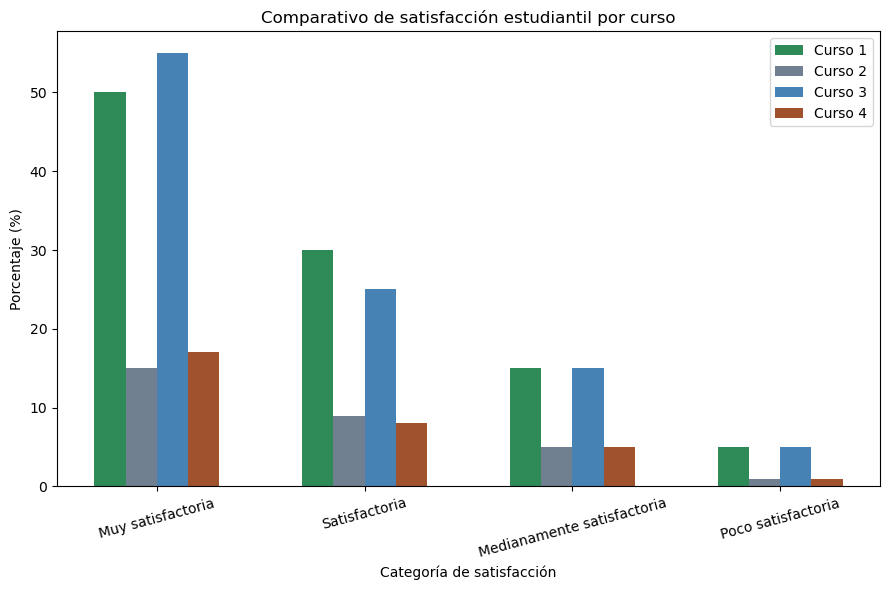

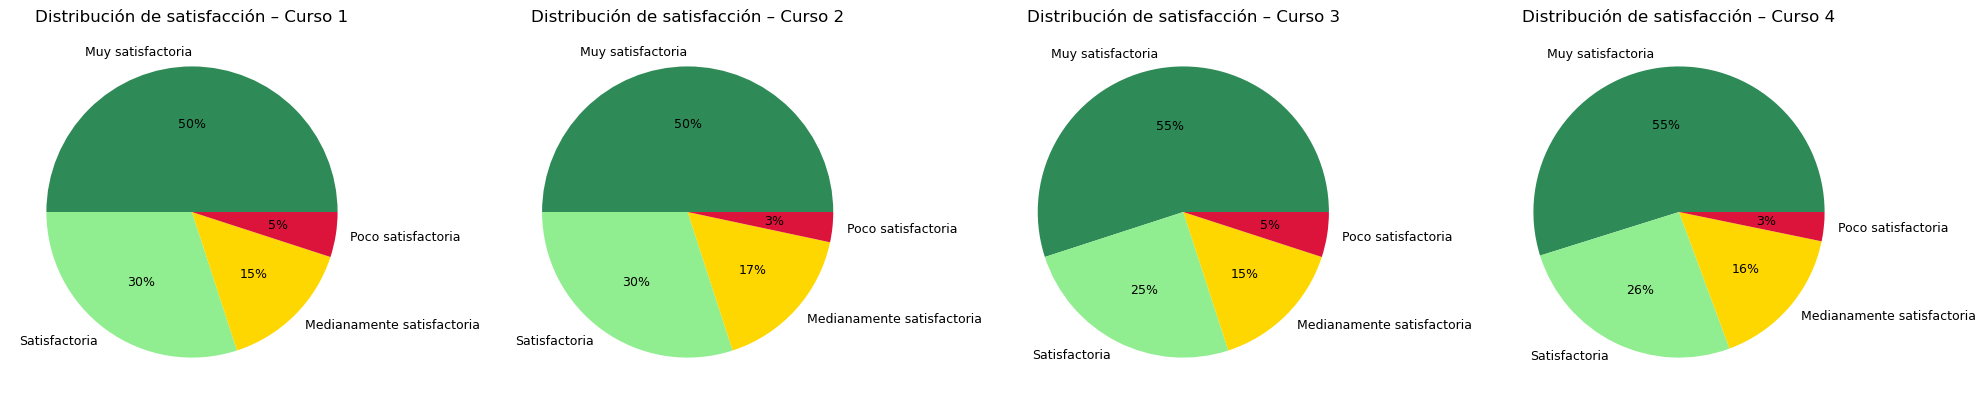


✅ Gráficos generados y guardados como:
   - grafico_comparativo.png
   - graficos_circulares.png


In [1]:
# ============================================
# Análisis de Satisfacción Estudiantil
# Genera gráficos dinámicos (2 a 4 cursos)
# Autor: Paul Gálvez / Grupo 12
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Función para ingresar datos
# -----------------------------
def ingresar_datos():
    print("\n--- Ingreso de datos ---")
    num_cursos = 0
    while num_cursos < 2 or num_cursos > 4:
        num_cursos = int(input("Ingrese la cantidad de cursos (mínimo 2, máximo 4): "))

    categorias = ["Muy satisfactoria", "Satisfactoria", "Medianamente satisfactoria", "Poco satisfactoria"]
    data = {"Categoría de Satisfacción": categorias}

    # Ingreso de datos por curso
    for i in range(1, num_cursos + 1):
        print(f"\nIngrese los porcentajes para el Curso {i}:")
        porcentajes = []
        for cat in categorias:
            valor = float(input(f"  {cat}: "))
            porcentajes.append(valor)
        data[f"Curso {i} (%)"] = porcentajes

    df = pd.DataFrame(data)
    return df, num_cursos

# -----------------------------
# Función para graficar resultados
# -----------------------------
def graficar_resultados(df, num_cursos):
    # Colores institucionales sobrios
    colores = ["#2E8B57", "#708090", "#4682B4", "#A0522D"]

    # Gráfico comparativo de barras
    plt.figure(figsize=(9,6))
    bar_width = 0.15
    x = range(len(df))
    for i in range(num_cursos):
        plt.bar(
            [p + bar_width*i for p in x],
            df[f"Curso {i+1} (%)"],
            width=bar_width,
            label=f"Curso {i+1}",
            color=colores[i]
        )

    plt.xlabel("Categoría de satisfacción")
    plt.ylabel("Porcentaje (%)")
    plt.title("Comparativo de satisfacción estudiantil por curso")
    plt.xticks([p + bar_width*(num_cursos/2-0.5) for p in x], df["Categoría de Satisfacción"], rotation=15)
    plt.legend()
    plt.tight_layout()
    plt.savefig("grafico_comparativo.png", dpi=300)
    plt.show()

    # Gráficos circulares individuales
    fig, axes = plt.subplots(1, num_cursos, figsize=(5*num_cursos,5))
    if num_cursos == 1:
        axes = [axes]
    colors_pie = ["#2E8B57", "#90EE90", "#FFD700", "#DC143C"]

    for i in range(num_cursos):
        axes[i].pie(
            df[f"Curso {i+1} (%)"],
            labels=df["Categoría de Satisfacción"],
            autopct='%1.0f%%',
            colors=colors_pie,
            textprops={'fontsize': 9}
        )
        axes[i].set_title(f"Distribución de satisfacción – Curso {i+1}")
    plt.tight_layout()
    plt.savefig("graficos_circulares.png", dpi=300)
    plt.show()

# -----------------------------
# Ejecución principal
# -----------------------------
if __name__ == "__main__":
    df, num_cursos = ingresar_datos()
    print("\nDatos ingresados:\n", df)
    graficar_resultados(df, num_cursos)
    print("\n✅ Gráficos generados y guardados como:")
    print("   - grafico_comparativo.png")
    print("   - graficos_circulares.png")

